# Выявление мошенничества при операциях с кредитными картами
--- 

# Разведочный анализ данных (EDA)

### Подключение библиотек

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

### Загрузка данных

In [ ]:
df = pd.read_csv("fraudTrain.csv")

### Функции

In [ ]:
def numerical_distribution(num, title, x, y):
    df[num].plot(kind='hist', bins = 20)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)

In [ ]:
def category_distribution(category, title, x, y):
    df[category].value_counts().plot(kind='bar')
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)

## Первичный обзор данных

In [ ]:
df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [ ]:
df.shape

(1296675, 23)

In [ ]:
df.isna().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

### Вывод по структуре данных

Анализ структуры данных показывает, что датасет содержит **1 296 675 транзакций и 23 признака**

Пропущенные значения в данных отсутствуют, что упрощает дальнейший анализ

## Предобработка данных

In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [ ]:
df['trans_date'] = df['trans_date_trans_time'].dt.date
df['trans_hour'] = df['trans_date_trans_time'].dt.hour

In [ ]:
df = df.drop('trans_date_trans_time', axis=1)

In [ ]:
drop_cols = [
    'Unnamed: 0',
    'cc_num',
    'first',
    'last',
    'street',
    'trans_num'
]

df = df.drop(columns=drop_cols)

In [ ]:
df['distance'] = np.sqrt(
    (df['lat'] - df['merch_lat'])**2 +
    (df['long'] - df['merch_long'])**2
)

## Анализ целевой переменной (is_fraud)

In [ ]:
df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

<Axes: xlabel='is_fraud'>

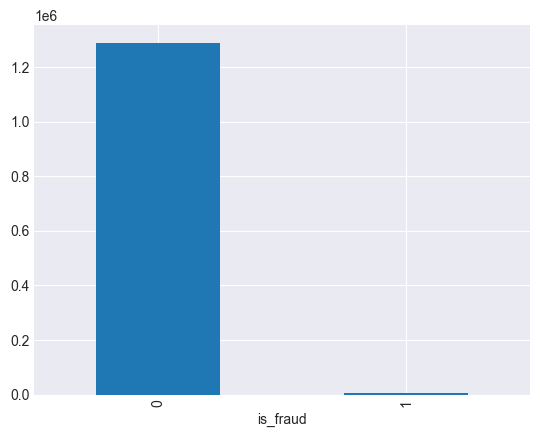

In [ ]:
df['is_fraud'].value_counts().plot(kind='bar')

**Вывод**

Анализ целевой переменной показывает, что подавляющее большинство транзакций в наборе данных являются легитимными. Доля мошеннических операций составляет около **0,6%** от общего количества транзакций.

Таким образом, наблюдается **дисбаланс классов**, при котором класс обычных транзакций значительно преобладает над мошенническими. 

---

## Анализ числовых признаков

### Сумма транзакции (amt)

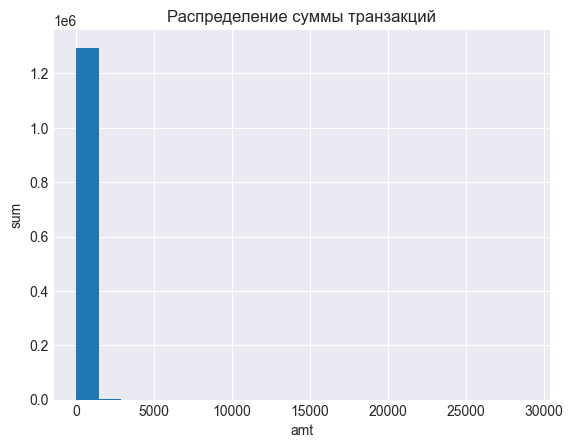

In [ ]:
numerical_distribution('amt', 'Распределение суммы транзакций', 'amt', 'sum')

**Вывод**

Распределение суммы транзакций сильно смещено вправо. 

Большинство операций имеет небольшие суммы, при этом присутствуют редкие крупные транзакции (выбросы).

### Расcтояние между клиентом и продавцом

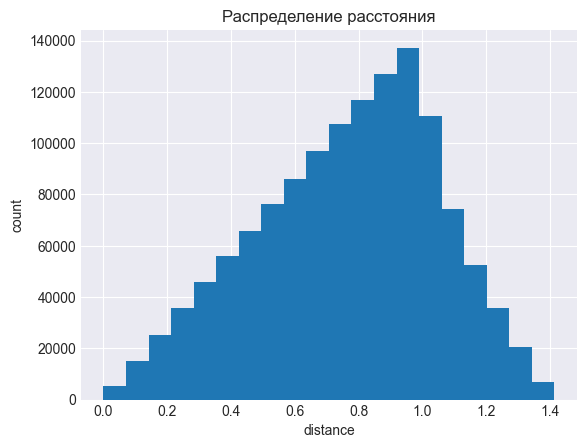

In [ ]:
numerical_distribution('distance','Распределение расстояния', 'distance', 'count')

**Вывод**

Распределение расстояния между клиентом и продавцом близко к симметричному.

Большинство транзакций совершается на расстоянии 0.7–1.1 км.

### Население города (City Population)

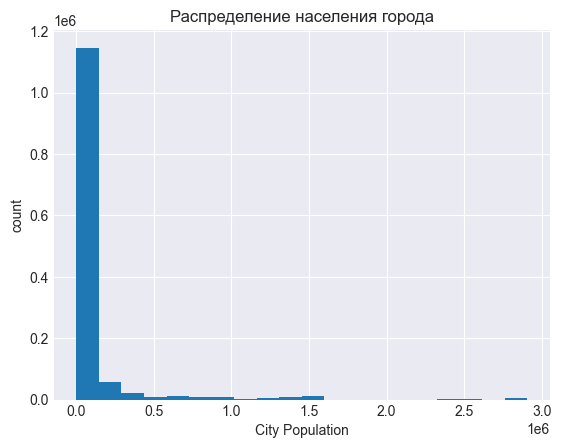

In [ ]:
numerical_distribution('city_pop', 'Распределение населения города', 'City Population', 'count')

**Вывод**

Распределение населения сильно смещено вправо.

Большинство городов имеют небольшое население. Присутствует небольшое количество городов с очень большим населением (выбросы)

## Анализ временных признаков

### Время суток

<Axes: xlabel='trans_hour'>

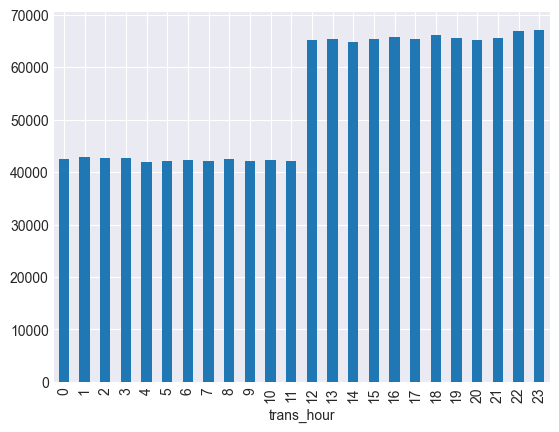

In [ ]:
df['trans_hour'].value_counts().sort_index().plot(kind='bar')

**Вывод**

Количество транзакций увеличивается после полудня. 

В утренние часы активность ниже, тогда как во второй половине дня наблюдается более высокая частота операций.

## Анализ категориальных признаков

### Категория продавца (Category)

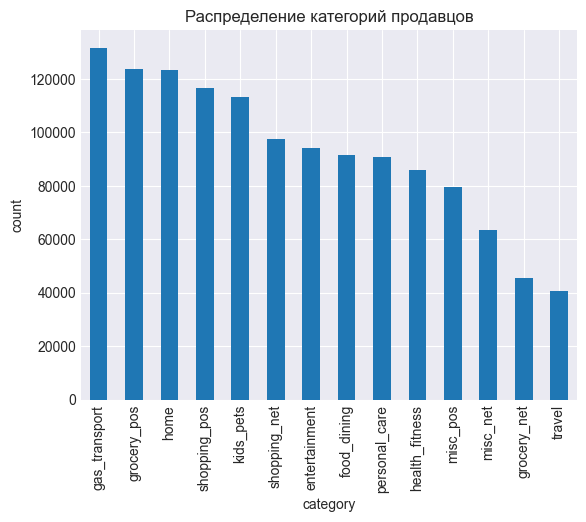

In [ ]:
category_distribution('category', 'Распределение категорий продавцов', 'category', 'count')

**Вывод**

Распределение категорий продавцов неравномерное: 

некоторые категории встречаются значительно чаще других, 
в частности gas_transport и grocery_pos, тогда как travel и grocery_net представлены реже.



### Профессия клиента (Job)

Text(0.5, 1.0, 'Топ 10 профессий')

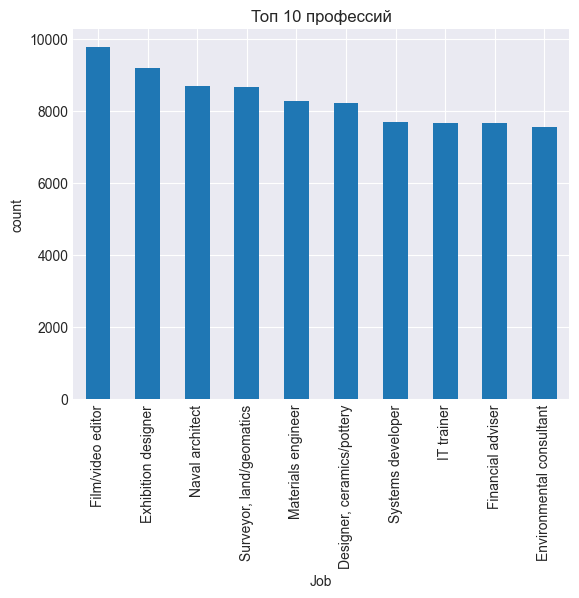

In [ ]:
top_10_job = df['job'].value_counts().head(10)
top_10_job.plot(kind='bar')

plt.xlabel('Job')
plt.ylabel('count')
plt.title('Топ 10 профессий')

**Вывод**

В топ-10 профессий входят Film/video editor, Exhibition designer и Naval architect. 

Частота встречаемости профессий внутри топа распределена достаточно равномерно и без резкого доминирования одной категории.

Полный список профессий значительно выше, что указывает на разнообразие клиентов.

---

## Анализ взаимосвязей признаков

### Корелляции признаков

<Axes: >

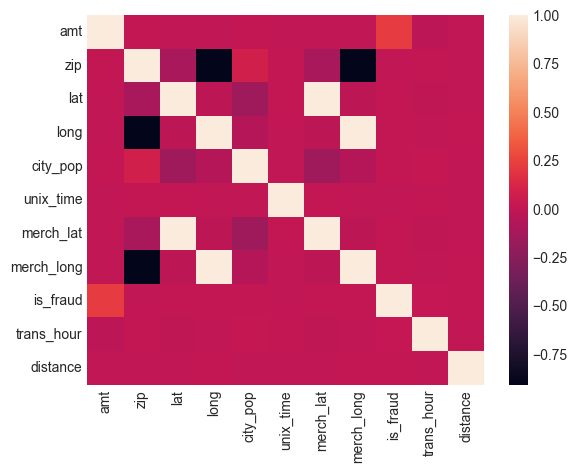

In [ ]:
sns.heatmap(df.corr(numeric_only=True))

**Вывод**

Анализ корреляционной матрицы показывает, что большинство признаков слабо коррелируют между собой.

Наиболее сильные зависимости наблюдаются между географическими признаками (lat, long и координаты продавца), что объясняется их природой.

При этом целевая переменная (is_fraud) не демонстрирует выраженной линейной корреляции с другими признаками, что может указывать на отсутствие простых линейных зависимостей и необходимость использования моделей машинного обучения для выявления сложных паттернов.

### Числовые признаки vs Fraud

<Axes: xlabel='is_fraud', ylabel='amt'>

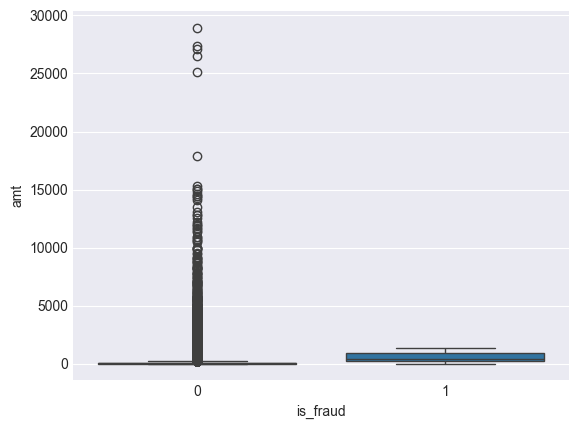

In [ ]:
sns.boxplot(x='is_fraud', y='amt', data=df)

**Вывод**

Для мошеннических транзакций характерны более высокие значения суммы по сравнению с обычными операциями. 

При этом для не мошеннических транзакций наблюдается большое количество выбросов, однако в целом их медиана ниже.

<Axes: xlabel='is_fraud', ylabel='distance'>

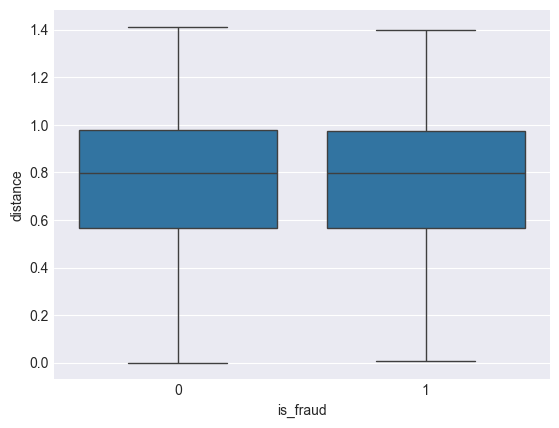

In [ ]:
sns.boxplot(x='is_fraud', y='distance', data=df)

**Вывод**

Значимых различий в распределении расстояния между мошенническими и обычными транзакциями не наблюдается, что указывает на слабую информативность данного признака.

<Axes: xlabel='is_fraud', ylabel='city_pop'>

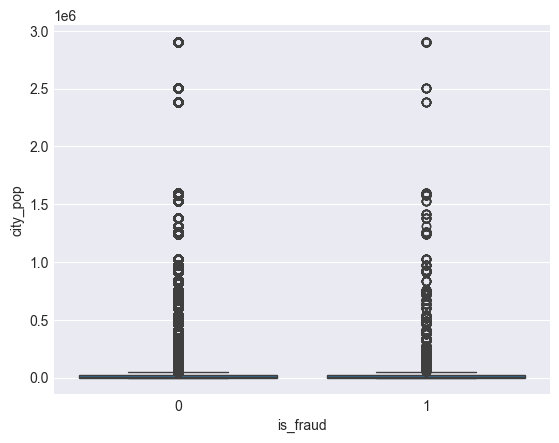

In [ ]:
sns.boxplot(x='is_fraud', y='city_pop', data=df)

**Вывод**

Значимых различий в распределении населения города между мошенническими и обычными транзакциями не наблюдается, что указывает на слабую информативность данного признака.

### Категориальные признаки vs Fraud


<Axes: xlabel='category'>

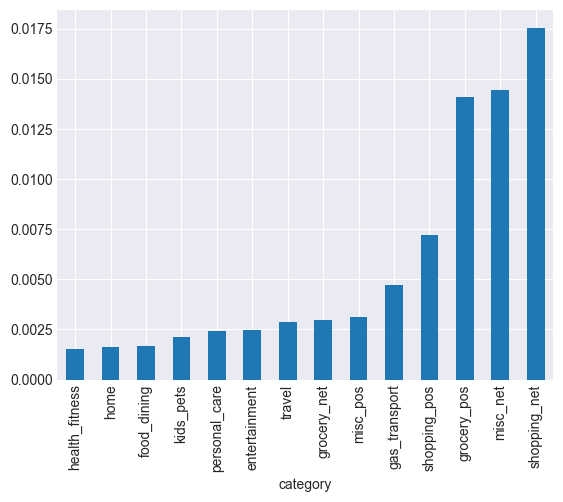

In [ ]:
df.groupby('category')['is_fraud'].mean().sort_values().plot(kind='bar')

**Вывод**

Анализ категорий продавцов показывает наличие различий в доле мошеннических транзакций между категориями. 

Некоторые категории (например shopping_net и misc_net) демонстрируют более высокий уровень мошенничества, тогда как другие (например health_fitness и home) характеризуются более низкой долей fraud. 

Это указывает на потенциальную информативность данного признака для модели.

---

# Построение модели машинного обучения

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df.columns

Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'trans_date', 'trans_hour', 'distance'],
      dtype='object')

In [ ]:
df_ml = df.drop(columns=['trans_date',
                        'trans_hour',
                        'unix_time',
                        'merchant',
                        'city',
                        'job'])

In [ ]:
X = df_ml.drop('is_fraud', axis=1)
y = df_ml['is_fraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train=pd.get_dummies(X_train, drop_first=True)
X_test=pd.get_dummies(X_test, drop_first=True)

In [ ]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=8,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1 
)
rf_model.fit(X_train, y_train);

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    257815
           1       0.08      0.77      0.14      1520

    accuracy                           0.95    259335
   macro avg       0.54      0.86      0.56    259335
weighted avg       0.99      0.95      0.97    259335



**Вывод**

Модель Random Forest демонстрирует высокую полноту (recall) для класса мошенничества, что позволяет выявлять большую часть мошеннических транзакций. 

Однако точность (precision) остается низкой, что указывает на большое количество ложноположительных срабатываний.

Таким образом, модель склонна переоценивать вероятность мошенничества, что может приводить к избыточным проверкам, но при этом снижает риск пропуска реальных мошеннических операций.

## ROC-AUC

In [ ]:
y_proba = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
roc_auc = roc_auc_score(y_test, y_proba)
print(roc_auc)

0.8837232047255427


Text(0, 0.5, 'True Positive Rate')

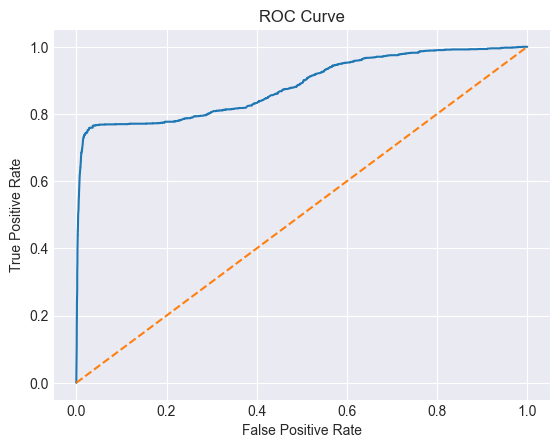

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')


# Итоговый вывод

- Данные имеют сильный дисбаланс классов, что усложняет задачу обнаружения мошенничества  
- Без балансировки модели практически игнорируют класс fraud  
- Использование `class_weight='balanced'` увеличивает recall, но снижает precision  
- ROC-AUC ≈ 0.88 показывает, что модель хорошо различает классы на уровне вероятностей  
- Итоговое качество модели сильно зависит от выбранного порога классификации  

В целом, задача требует компромисса между precision и recall в зависимости от бизнес-целей.